# 2D Stokes Flow simulation using PINN Based model


### Step 1: import the required libraries.

In [ ]:
import numpy as np
import torch 
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.autograd
from torch.optim.lr_scheduler import ReduceLROnPlateau

### Step 2: Setup the grid, and boundary positions, which will be required when computing the loss terms. The grid is combined into a single tensor, which is then directly fed into the network


In [22]:
dimension = 64
x_domain = torch.linspace(0,1,dimension)
y_domain = torch.linspace(0,1,dimension)
n = dimension**2
x_y = torch.zeros(n,2)
x_y_boundary1 = torch.zeros((dimension-2),2)
x_y_boundary2 = torch.zeros((dimension-2),2)
x_y_boundary3 = torch.zeros((dimension-2),2)
x_y_boundary4 = torch.zeros((dimension-2),2)
n1 = 0
n2 = 0
n3 = 0
n4 = 0
for i in range(dimension):
    for j in range(dimension):
        x_y[dimension*i+j,0] = x_domain[i]
        x_y[dimension*i+j,1] = y_domain[j]
        
        #left boundary 4
        if x_domain[i] < 0.01 and 0.01 < y_domain[j] < 0.99:
            x_y_boundary4[n1,0] = x_domain[i]
            x_y_boundary4[n1,1] = y_domain[j]
            n1 += 1

        #right boundary 2
        if x_domain[i] > 0.99 and  0.01 < y_domain[j] < 0.99:
            x_y_boundary2[n2,0] = x_domain[i]
            x_y_boundary2[n2,1] = y_domain[j]
            n2 += 1

        #bottom boundary 1
        if 0.01 < x_domain[i] < 0.99 and y_domain[j] < 0.01:
            x_y_boundary1[n3,0] = x_domain[i]
            x_y_boundary1[n3,1] = y_domain[j]
            n3 += 1

        #top boundary 3
        if 0.01 < x_domain[i] < 0.99 and y_domain[j] > 0.99:
            x_y_boundary3[n4,0] = x_domain[i]
            x_y_boundary3[n4,1] = y_domain[j]
            n4 += 1

x_y.requires_grad_(True)

mu = 1 

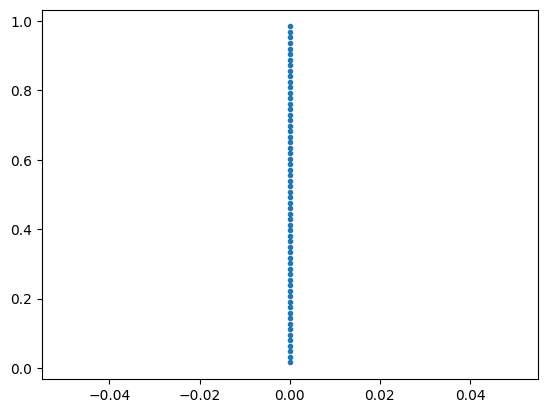

In [3]:
x_y_Test = x_y.detach().numpy()
plt.plot(x_y_Test[:,1],x_y_Test[:,0],'.')

### Step 3: Setup the boundary conditions

In [4]:
U_1 = torch.zeros(dimension-2,1)
U_2 = torch.zeros(dimension-2,1)
U_3 = torch.zeros(dimension-2,1)
U_4 = torch.zeros(dimension-2,1)
V_1 = torch.zeros(dimension-2,1)
V_2 = torch.zeros(dimension-2,1)
V_3 = torch.zeros(dimension-2,1)
V_4 = torch.zeros(dimension-2,1)
P_1 = torch.zeros(dimension-2,1)
P_2 = torch.zeros(dimension-2,1)
P_3 = torch.zeros(dimension-2,1)
P_4 = torch.zeros(dimension-2,1)
# 1 is the bottom boundary
U_1[:]=0
V_1[:]= 0
P_1[:] = 0
# 2 is the right boundary
U_2[:]= 0
V_2[:]= 0
P_2[:] = 0
# 3 is the top boundary
U_3[:]= 0
V_3[:]= 0
P_3[:]= 0
# 4 is the left boundary
U_4[:]= 1
V_4[:]= 0
P_4[:] = 0


### Step 4: Setting up our neural network architecture. The forward method describes how data flow through the neural net


In [5]:
class PINN_stokes(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2,64)
        self.layer2 = nn.Linear(64,128)
        self.layer3 = nn.Linear(128,64)
        self.layer4 = nn.Linear(64,3)
        self.activ = nn.Tanh()

    def forward(self,xy):
        m = self.activ(self.layer1(xy))
        m = self.activ(self.layer2(m))
        m = self.activ(self.layer3(m))
        m = self.layer4(m)
        return m



The following block loads a file with the previously trained weights

In [23]:
stokes_nn = PINN_stokes()
stokes_nn.load_state_dict(torch.load('Stokes_flow_exit.pth'))

<All keys matched successfully>

### Step 5: This is one of the most important part of the PINN model. The following function compute the Loss of the model given all the parameters. In the first part, we use autograd, to extend backprop to the inputs layer and compute the differentials of our output variables with respect to the spatial coordinates. Then we compute our momentum and continuity equations. Finally the boundary conditions are imposed at the boundary points as another function of the losses.

In [7]:
def compute_loss(model, x_y,x_y_boundary1,x_y_boundary2,x_y_boundary3,x_y_boundary4,U_1,V_1,U_2,V_2,U_3,V_3,U_4,V_4,P_1,P_2,P_3,P_4,mu):
    output = model(x_y)
    U = output[:,0:1]
    V = output[:,1:2]
    P = output[:,2:3]

    du = torch.autograd.grad(U, x_y , grad_outputs=torch.ones_like(U), create_graph = True)[0]
    dv= torch.autograd.grad(V, x_y , grad_outputs=torch.ones_like(V), create_graph = True)[0]
    dp = torch.autograd.grad(P, x_y , grad_outputs=torch.ones_like(P), create_graph = True)[0]

    du_dx = du[:, 0:1]
    du_dy = du[:, 1:2]
    dv_dx = dv[:, 0:1]
    dv_dy = dv[:, 1:2]

    d2u_dx2 = torch.autograd.grad(du_dx, x_y, grad_outputs=torch.ones_like(du_dx), create_graph=True)[0][:, 0:1]
    d2u_dy2 = torch.autograd.grad(du_dy, x_y, grad_outputs=torch.ones_like(du_dy), create_graph=True)[0][:, 1:2]

    d2v_dx2 = torch.autograd.grad(dv_dx, x_y, grad_outputs=torch.ones_like(dv_dx), create_graph=True)[0][:, 0:1]
    d2v_dy2 = torch.autograd.grad(dv_dy, x_y, grad_outputs=torch.ones_like(dv_dy), create_graph=True)[0][:, 1:2]

    
    dp_dx = dp[:,0:1]
    dp_dy = dp[:,1:2]

    # x- momentum

    x_momentum_tensor = mu*(d2u_dx2 + d2u_dy2) - dp_dx
    loss_x_momentum = torch.mean(x_momentum_tensor**2)

    y_momentum_tensor = mu*(d2v_dx2 + d2v_dy2) - dp_dy
    loss_y_momentum = torch.mean(y_momentum_tensor**2)

    continuity_tensor = du_dx + dv_dy
    loss_continuity = torch.mean(continuity_tensor**2)

    #setup boundary conditions loss
    loss_boundary = 0
    b1 = model(x_y_boundary1)
    U_1_model = b1[:,0:1]
    V_1_model = b1[:,1:2]
    P_1_model = b1[:,2:3]
    b2 = model(x_y_boundary2)
    U_2_model = b2[:,0:1]
    V_2_model = b2[:,1:2]
    P_2_model = b2[:,2:3]
    b3 = model(x_y_boundary3)
    U_3_model = b3[:,0:1]
    V_3_model = b3[:,1:2]
    P_3_model = b3[:,2:3]
    b4 = model(x_y_boundary4)
    U_4_model = b4[:,0:1]
    V_4_model = b4[:,1:2]
    P_4_model = b4[:,2:3]

    l1 = (U_1_model - U_1)**2 + (V_1_model - V_1)**2
    loss_boundary += torch.mean(l1)

    l2 = (P_2_model - P_2)**2  # pressure exit condition implemented, assuming fully developed. 
    loss_boundary += torch.mean(l2)  #higher weight assigned to pressure field
    
    l3 = (U_3_model - U_3)**2 + (V_3_model - V_3)**2
    loss_boundary += torch.mean(l3)
    
    l4 = (U_4_model - U_4)**2 + (V_4_model - V_4)**2 #control the inlet pressure
    loss_boundary += torch.mean(l4)

    return 2*loss_boundary + loss_x_momentum + loss_y_momentum + loss_continuity, loss_boundary, loss_continuity, loss_x_momentum, loss_y_momentum



    
    

### Step 6: Setup and run the optimization loop. The 2 following blocks setup the optimizer, the scheduler and train the model by computing the gradients of the loss term with respect to weights in the network. Then the process of stochastic gradient descent is employed to slowly move towards a minima.

In [24]:
optimizer = optim.Adam(stokes_nn.parameters(),lr = 0.005)
scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience = 200)

In [ ]:
for epochs in range(0,200000):
    optimizer.zero_grad()
    loss, loss_bound, loss_continuity, loss_x_mom, loss_y_mom = compute_loss(stokes_nn,x_y,x_y_boundary1,x_y_boundary2,x_y_boundary3,x_y_boundary4,U_1,V_1,U_2,V_2,U_3,V_3,U_4,V_4,P_1,P_2,P_3,P_4,mu)
    loss.backward()
    optimizer.step()
    scheduler.step(loss)
    if epochs % 10 == 0:
        print(f'Epoch {epochs}, LR: {scheduler.get_last_lr()}, Loss Total : {loss}, Loss boundary condition : {loss_bound}, Loss continuity  : {loss_continuity}, Loss x mom : {loss_x_mom}, Loss y mom : {loss_y_mom}', end="\r", flush=True)

## POST PROCESSING RESULTS

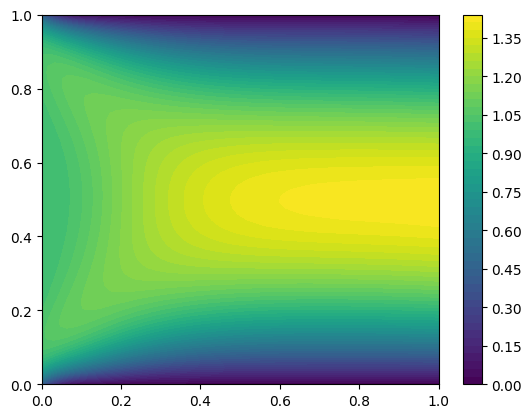

In [9]:
with torch.no_grad():
    output = stokes_nn(x_y)
    U_pred = output[:,0:1].detach().numpy().reshape(dimension,dimension)
    V_pred = output[:,1:2].detach().numpy().reshape(dimension,dimension)
    P_pred = output[:,2:3].detach().numpy().reshape(dimension,dimension)
vel_mag = np.sqrt(U_pred**2 + V_pred**2)
x_plot = x_y[:,0].detach().numpy().reshape(dimension,dimension)
y_plot = x_y[:,1].detach().numpy().reshape(dimension,dimension)
plt.contourf(x_plot,y_plot,vel_mag,50)
plt.colorbar()

Contours of the velocity magnitude

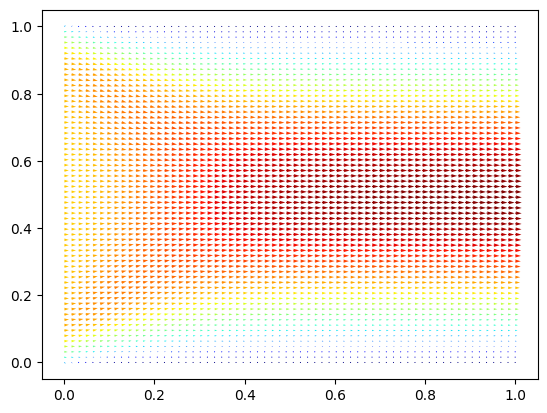

In [10]:
plt.quiver(x_plot,y_plot,U_pred,V_pred,vel_mag,cmap = 'jet')

Quiver plot showing flow direction

The following block saves the weights of the currently trained model

In [26]:
torch.save(stokes_nn.state_dict(),'Stokes_flow_exit.pth')

In [28]:
tensor = torch.tensor([[0.95,0.5]])
out = stokes_nn(tensor)
U_center_pred = out[0,0].item()
U_analytical = 1.5
acc = (U_analytical-U_center_pred)/U_analytical
print(f'The Predicted centerline velocity at flow exit for developed flow is {100 - acc*100}% Accurate')

The Predicted centerline velocity at flow exit for developed flow is 95.45137882232666% Accurate
